In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [3]:
df = pd.read_csv("../data/processed/ola_cleaned.csv")
df.head()

,Date,Time,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,V_TAT,C_TAT,...,Incomplete_Rides_Reason,Booking_Value,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating,Vehicle Images,Ride_Day,Ride_Month,Ride_Hour
0,2024-07-26 14:00:00,14:00:00,CNR7153255142,Canceled by Driver,CID713523,Prime Sedan,Tumkur Road,RT Nagar,NaN,NaN,...,Not Applicable,444,Unknown,0,NaN,NaN,https://cdn-icons-png.flaticon.com/128/14183/1...,Friday,7,14
1,2024-07-25 22:20:00,22:20:00,CNR2940424040,Success,CID225428,Bike,Magadi Road,Varthur,203.0,30.0,...,Not Applicable,158,Cash,13,4.1,4.0,https://cdn-icons-png.flaticon.com/128/9983/99...,Thursday,7,22
2,2024-07-30 19:59:00,19:59:00,CNR2982357879,Success,CID270156,Prime SUV,Sahakar Nagar,Varthur,238.0,130.0,...,Not Applicable,386,UPI,40,4.2,4.8,https://cdn-icons-png.flaticon.com/128/9983/99...,Tuesday,7,19
3,2024-07-22 03:15:00,03:15:00,CNR2395710036,Canceled by Customer,CID581320,eBike,HSR Layout,Vijayanagar,NaN,NaN,...,Not Applicable,384,Unknown,0,NaN,NaN,https://cdn-icons-png.flaticon.com/128/6839/68...,Monday,7,3
4,2024-07-02 09:02:00,09:02:00,CNR1797421769,Success,CID939555,Mini,Rajajinagar,Chamarajpet,252.0,80.0,...,Not Applicable,822,Credit Card,45,4.0,3.0,https://cdn-icons-png.flaticon.com/128/3202/32...,Tuesday,7,9


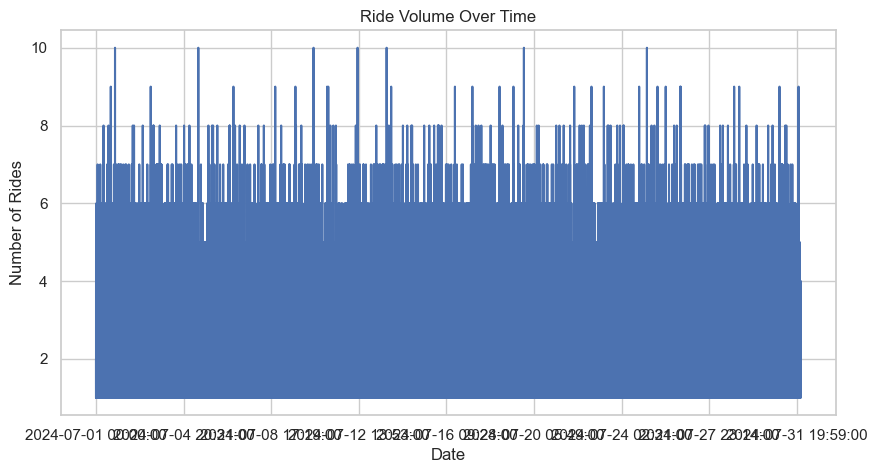

In [5]:
plt.figure(figsize=(10,5))
df['Date'].value_counts().sort_index().plot()
plt.title("Ride Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Rides")
plt.show()

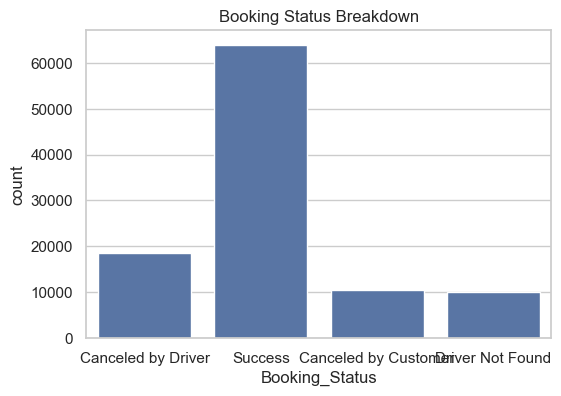

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Booking_Status')
plt.title("Booking Status Breakdown")
plt.show()

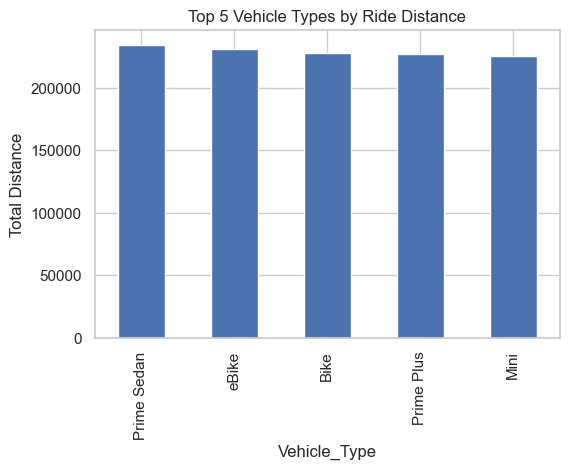

In [9]:
top_vehicle = (
    df.groupby('Vehicle_Type')['Ride_Distance']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top_vehicle.plot(kind='bar', figsize=(6,4), title="Top 5 Vehicle Types by Ride Distance")
plt.ylabel("Total Distance")
plt.show()

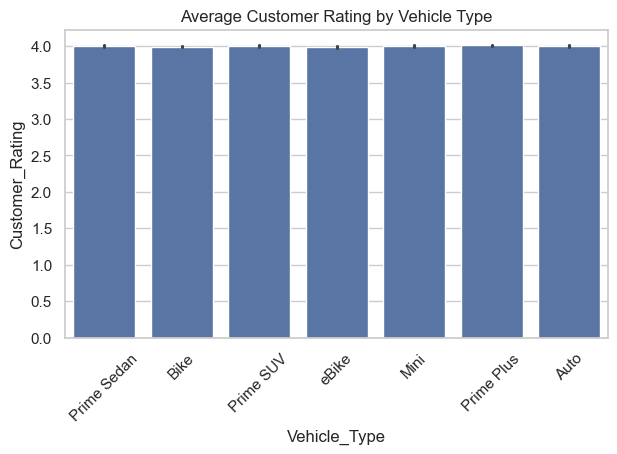

In [19]:
plt.figure(figsize=(7,4))
sns.barplot(
    data=df,
    x='Vehicle_Type',
    y='Customer_Rating',
    estimator='mean'
)
plt.title("Average Customer Rating by Vehicle Type")
plt.xticks(rotation=45)
plt.show()

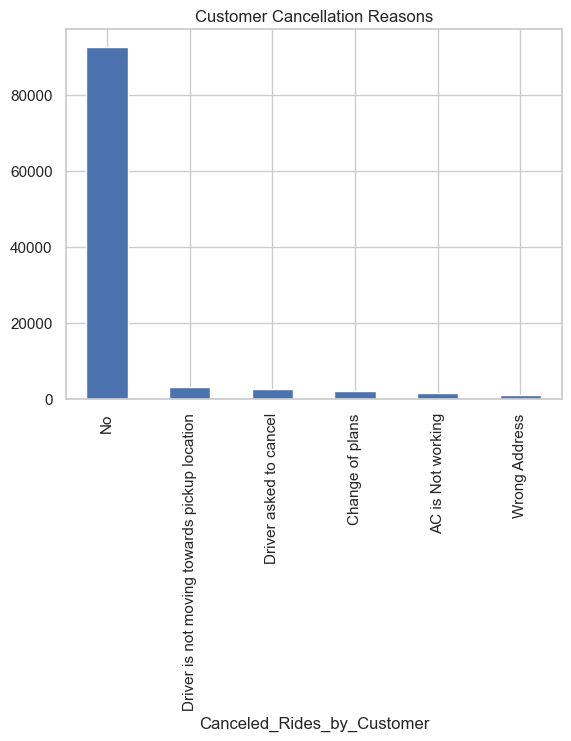

In [21]:
df['Canceled_Rides_by_Customer'].value_counts().plot(kind='bar')
plt.title("Customer Cancellation Reasons")
plt.show()

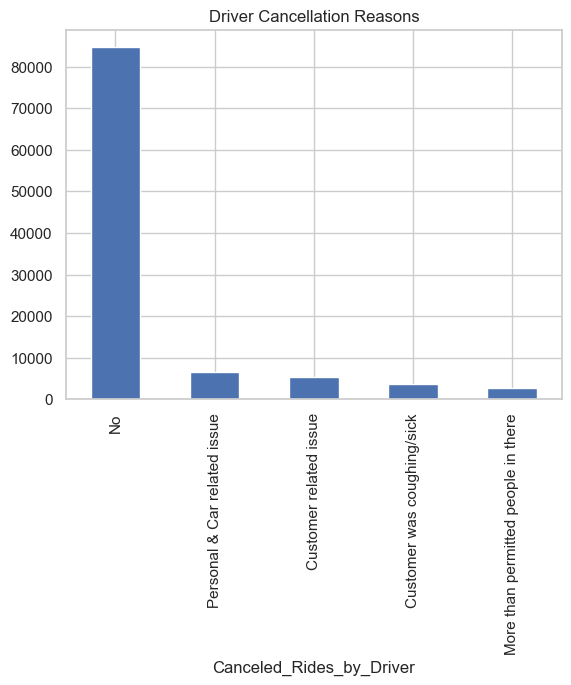

In [23]:
df['Canceled_Rides_by_Driver'].value_counts().plot(kind='bar')
plt.title("Driver Cancellation Reasons")
plt.show()

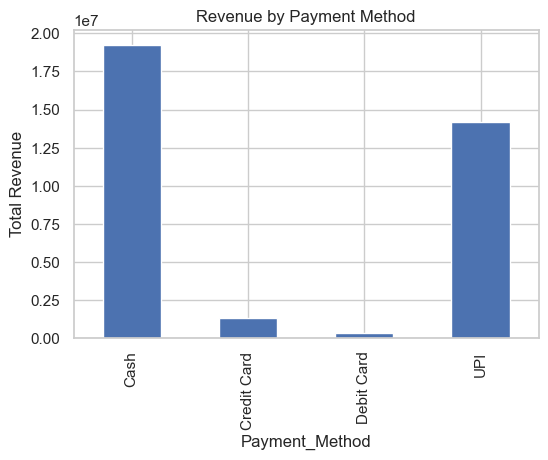

In [25]:
payment_revenue = (
    df[df['Booking_Status'] == 'Success']
    .groupby('Payment_Method')['Booking_Value']
    .sum()
)

payment_revenue.plot(kind='bar', figsize=(6,4))
plt.title("Revenue by Payment Method")
plt.ylabel("Total Revenue")
plt.show()

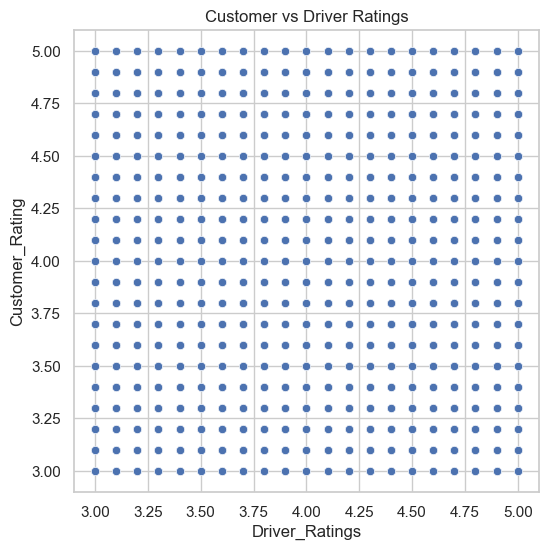

In [27]:
plt.figure(figsize=(6,6))
sns.scatterplot(
    data=df,
    x='Driver_Ratings',
    y='Customer_Rating'
)
plt.title("Customer vs Driver Ratings")
plt.show()